In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from rl_setup import STEM_environment, simulation_parameters, STEM_environment_history
import os
import ray
from ray.tune.registry import register_env
from ray.rllib.algorithms.ppo import PPO
import os
from tqdm import tqdm

# this is to only use 1 CPU and GPU 0 of the cluster
GPU_USE = 0
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # consistent GPU ordering
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_USE)
os.environ["OMP_NUM_THREADS"] = "1"

2025-11-12 13:45:31.223171: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 13:45:31.232775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762983931.245082  352513 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762983931.249239  352513 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762983931.259135  352513 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Environment test

Here we will test if the STEM_environment is properly defined.

STEM Environment Test Suite

=== Episode Summary ===
Total steps: 5
Total reward: -0.0270
Mean reward: -0.0054

All tests completed!


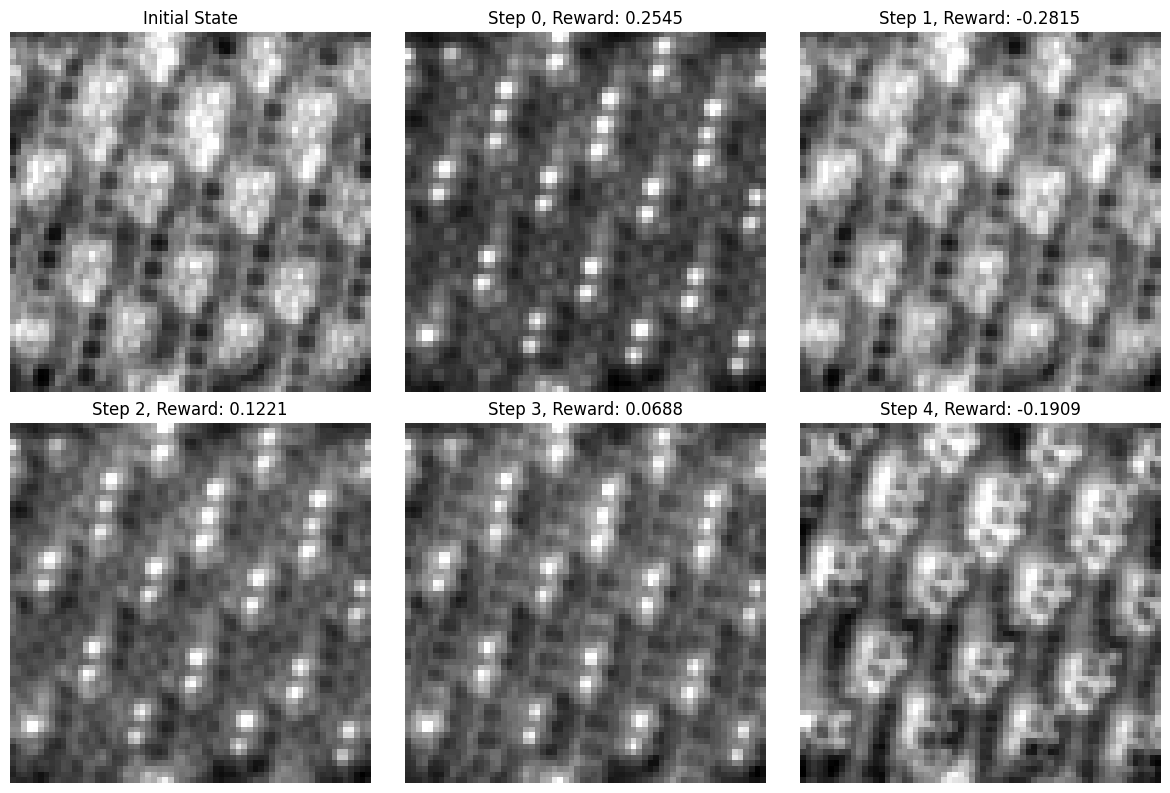

In [3]:


def test_env_basic():
    env = STEM_environment(config=simulation_parameters)

    obs, info = env.reset(seed=42)

    episode_rewards = []
    observations = [obs]
    
    for step_i in range(5):
        # sample random action from action space
        action = env.action_space.sample()
        
        obs, reward, terminated, truncated, info = env.step(action)
        
        episode_rewards.append(reward)
        observations.append(obs)
        
        if terminated or truncated:
            print("Episode ended early!")
            break
    
    print(f"\n=== Episode Summary ===")
    print(f"Total steps: {len(episode_rewards)}")
    print(f"Total reward: {sum(episode_rewards):.4f}")
    print(f"Mean reward: {np.mean(episode_rewards):.4f}")
    
    # Plot observations
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    axes[0].set_title("Initial State")
    
    for i, obs_img in enumerate(observations[:6]):
        axes[i].imshow(obs_img[:,:,0], cmap='gray')
        if i <= 4:
            axes[i+ 1].set_title(f'Step {i}, Reward: {episode_rewards[i]:.4f}')
        
        axes[i].axis('off')
    plt.tight_layout()
    fig.savefig('test_env_observations.png')
    
    return observations


def test_with_rllib():
    """Test with RLlib"""
    print("\n" + "="*60)
    print("Testing with RLlib...")
    
    ray.init(ignore_reinit_error=True, include_dashboard=False, num_cpus=2)
    
    def env_creator(cfg):
        return STEM_environment(config=cfg)
    
    register_env("stem_env", env_creator)
    
    config = {
        "env": "stem_env",
        "env_config": simulation_parameters,
        "num_workers": 0,
        "framework": "torch",
        "train_batch_size": 200,
        "rollout_fragment_length": 50,
        "model": {
            # CNN for image processing
            "conv_filters": [
                [16, [8, 8], 4],   # 16 filters, 8x8 kernel, stride 4
                [32, [4, 4], 2],   # 32 filters, 4x4 kernel, stride 2
                [64, [3, 3], 1],   # 64 filters, 3x3 kernel, stride 1
            ],
            "conv_activation": "relu",
            # MLP after CNN
            "fcnet_hiddens": [256, 256],
            "fcnet_activation": "relu",
            "free_log_std": True,
            "vf_share_layers": False,
        },
        "clip_param": 0.2,
        "entropy_coeff": 0.01,
        "lr": 3e-4,
        "gamma": 0.99,
    }
    
    print("Creating PPO trainer...")
    trainer = PPO(config=config)
    
    print("Running 2 training iterations...")
    for i in range(2):
        result = trainer.train()
        print(f"Iter {i+1}: reward_mean={result.get('episode_reward_mean', 0):.4f}")
    
    print("RLlib test passed!")
    ray.shutdown()
        


# Run tests
print("="*60)
print("STEM Environment Test Suite")
print("="*60)

# Test 1: Basic functionality
obs = test_env_basic()

# Test 2: Full episode
# test_env_episode()


print("\n" + "="*60)
print("All tests completed!")
print("="*60)

# Training

Here we will train the model with PPO

In [ ]:
ray.init(ignore_reinit_error=True,
         include_dashboard=False,
         num_cpus=2)

# Register the custom environment
def env_creator(cfg):
    return STEM_environment(config=cfg)

register_env("stem_env", env_creator)

# Base config 
config = {
    "env": "stem_env",
    "env_config": simulation_parameters,
    "num_workers": 0,
    "framework": "torch",
    "train_batch_size": 400,
    "rollout_fragment_length": 50,
    "grad_clip": 0.5,  # Gradient clipping
    "model": {
        "framestack": 3,  # can see last 3 observations
        "conv_filters": [
            [16, [4, 4], 2],
            [32, [3, 3], 2],
            [64, [3, 3], 1],
        ],
        "conv_activation": "relu",
        "fcnet_hiddens": [128, 128],
        "fcnet_activation": "relu",
        "free_log_std": True,
        "vf_share_layers": False,
    },
    "normalize_rewards": True, 
    "clip_param": 0.2,
    "entropy_coeff": 0,
    "lr": 5e-4,
    "gamma": 0.95,
    "vf_loss_coeff": 0.5,  # Add value function loss weight
    
}

# create PPO trainer
trainer = PPO(config=config)

# Long-running training parameters
num_iters = 400
checkpoint_root = "file://" + os.path.abspath("rllib_checkpoints") #save directory
os.makedirs(checkpoint_root, exist_ok=True)

# for i in tqdm(range(num_iters)):
#     result = trainer.train()
#     learner = result['learners']['default_policy']

#     # Save a checkpoint for this iteration
#     ckpt_path = trainer.save(checkpoint_root)
    
#     # Print only the important metrics
#     if i % 1 == 0:
#         print(f"\n{'='*50}")
#         print(f"Iteration {i+1}")
#         print(f"{'='*50}")
#         print(f"Explained Variance: {learner['vf_explained_var']:.4f}  (want: >0.5)")
#         print(f"Policy Loss: {learner['policy_loss']:.4f}  (want: negative)")
#         print(f"VF Loss: {learner['vf_loss']:.4f}  (want: <1.0)")
#         print(f"Entropy: {learner['entropy']:.4f}  (want: decreasing)")
#         print(f"KL Divergence: {learner['mean_kl_loss']:.4f}  (want: <0.05)")

for i in tqdm(range(num_iters)):
    result = trainer.train()
    learner = result['learners']['default_policy']

    # Save checkpoint every 10 iterations
    if i % 10 == 0:
        ckpt_path = trainer.save(checkpoint_root)
    
    # Print metrics
    if i % 1 == 0:
        print(f"\n{'='*50}")
        print(f"Iteration {i+1}")
        print(f"{'='*50}")
        print(f"Episode Reward Mean: {result.get('env_runners', {}).get('episode_reward_mean', 0):.4f}")
        print(f"Explained Variance: {learner['vf_explained_var']:.4f}  (want: >0.5)")
        print(f"Policy Loss: {learner['policy_loss']:.4f}")
        print(f"VF Loss: {learner['vf_loss']:.4f}  (want: <1.0)")
        print(f"Entropy: {learner['entropy']:.4f}  (want: decreasing)")
        print(f"KL Divergence: {learner['mean_kl_loss']:.4f}  (want: <0.05)")
        print(f"Entropy Coeff: {learner.get('entropy_coeff', 'N/A')}")

2025-11-12 16:10:31,011	INFO worker.py:1850 -- Calling ray.init() again after it has already been called.
2025-11-12 16:10:31,014	WARNING algorithm_config.py:5082 -- You configured a custom `model` config (probably through calling config.training(model=..), whereas your config uses the new API stack! In order to switch off the new API stack, set in your config: `config.api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)`. If you DO want to use the new API stack, configure your model, instead, through: `config.rl_module(model_config={..})`.
/home/hebell/miniconda3/envs/abtem_env/lib/python3.11/site-packages/ray/rllib/algorithms/algorithm.py:526: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/hebell/miniconda3/e


Iteration 1
Episode Reward Mean: 0.0000
Explained Variance: 0.4950  (want: >0.5)
Policy Loss: -0.1350
VF Loss: 0.3340  (want: <1.0)
Entropy: 5.6511  (want: decreasing)
KL Divergence: 0.0199  (want: <0.05)
Entropy Coeff: N/A


  0%|          | 2/400 [03:49<12:31:49, 113.34s/it]


Iteration 2
Episode Reward Mean: 0.0000
Explained Variance: 0.7132  (want: >0.5)
Policy Loss: -0.1730
VF Loss: 0.3372  (want: <1.0)
Entropy: 5.6565  (want: decreasing)
KL Divergence: 0.0302  (want: <0.05)
Entropy Coeff: N/A


  1%|          | 3/400 [05:23<11:31:57, 104.58s/it]

...


Iteration 51
Episode Reward Mean: 0.0000
Explained Variance: 0.7725  (want: >0.5)
Policy Loss: -0.2463
VF Loss: 0.7692  (want: <1.0)
Entropy: 5.1661  (want: decreasing)
KL Divergence: 0.0095  (want: <0.05)
Entropy Coeff: N/A


 13%|█▎        | 52/400 [2:02:57<19:09:58, 198.27s/it]


Iteration 52
Episode Reward Mean: 0.0000
Explained Variance: 0.7172  (want: >0.5)
Policy Loss: -0.3139
VF Loss: 0.8744  (want: <1.0)
Entropy: 5.0153  (want: decreasing)
KL Divergence: 0.0101  (want: <0.05)
Entropy Coeff: N/A


 13%|█▎        | 53/400 [2:06:59<20:23:07, 211.49s/it]


Iteration 53
Episode Reward Mean: 0.0000
Explained Variance: 0.6276  (want: >0.5)
Policy Loss: -0.2477
VF Loss: 1.3534  (want: <1.0)
Entropy: 5.1919  (want: decreasing)
KL Divergence: 0.0110  (want: <0.05)
Entropy Coeff: N/A


# Inference test

2025-11-11 14:51:29,970	INFO worker.py:2012 -- Started a local Ray instance.
2025-11-11 14:51:30,240	WARNING algorithm_config.py:5082 -- You configured a custom `model` config (probably through calling config.training(model=..), whereas your config uses the new API stack! In order to switch off the new API stack, set in your config: `config.api_stack(enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False)`. If you DO want to use the new API stack, configure your model, instead, through: `config.rl_module(model_config={..})`.
/home/hebell/miniconda3/envs/abtem_env/lib/python3.11/site-packages/ray/rllib/algorithms/algorithm.py:526: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/hebell/miniconda3/envs/abtem_env/lib/python3.11/

Loading checkpoint from: /data/shared/projects/CS230_HenryCedricNick/Notebooks/rllib_checkpoints


2025-11-11 14:51:30,591	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-11-11 14:51:30,600	INFO trainable.py:578 -- Restored on 171.67.84.181 from checkpoint: Checkpoint(filesystem=local, path=/data/shared/projects/CS230_HenryCedricNick/Notebooks/rllib_checkpoints)



Running test episode with trained policy...
Step 5: action=-0.4793, reward=-0.0023, cumulative=0.0271, focus=0.0733


(pid=gcs_server) [2025-11-11 14:51:32,625 E 155569 155569] (gcs_server) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


Step 10: action=-0.6795, reward=0.0020, cumulative=0.0250, focus=0.0712
Step 15: action=-1.0607, reward=-0.0008, cumulative=0.0284, focus=0.0746
Step 20: action=-1.0642, reward=0.0015, cumulative=0.0309, focus=0.0771
Step 25: action=-0.9945, reward=-0.0029, cumulative=0.0284, focus=0.0746
Step 30: action=-0.7430, reward=-0.0015, cumulative=0.0259, focus=0.0721

=== Episode Results ===
Total steps: 30
Total reward: 0.0259
Mean reward per step: 0.0009
Final focus metric: 0.0721
Final state: [-1. -1. -1. -1.]

Saved visualization to trained_model_episode.png
Saved reward plots to trained_model_rewards.png


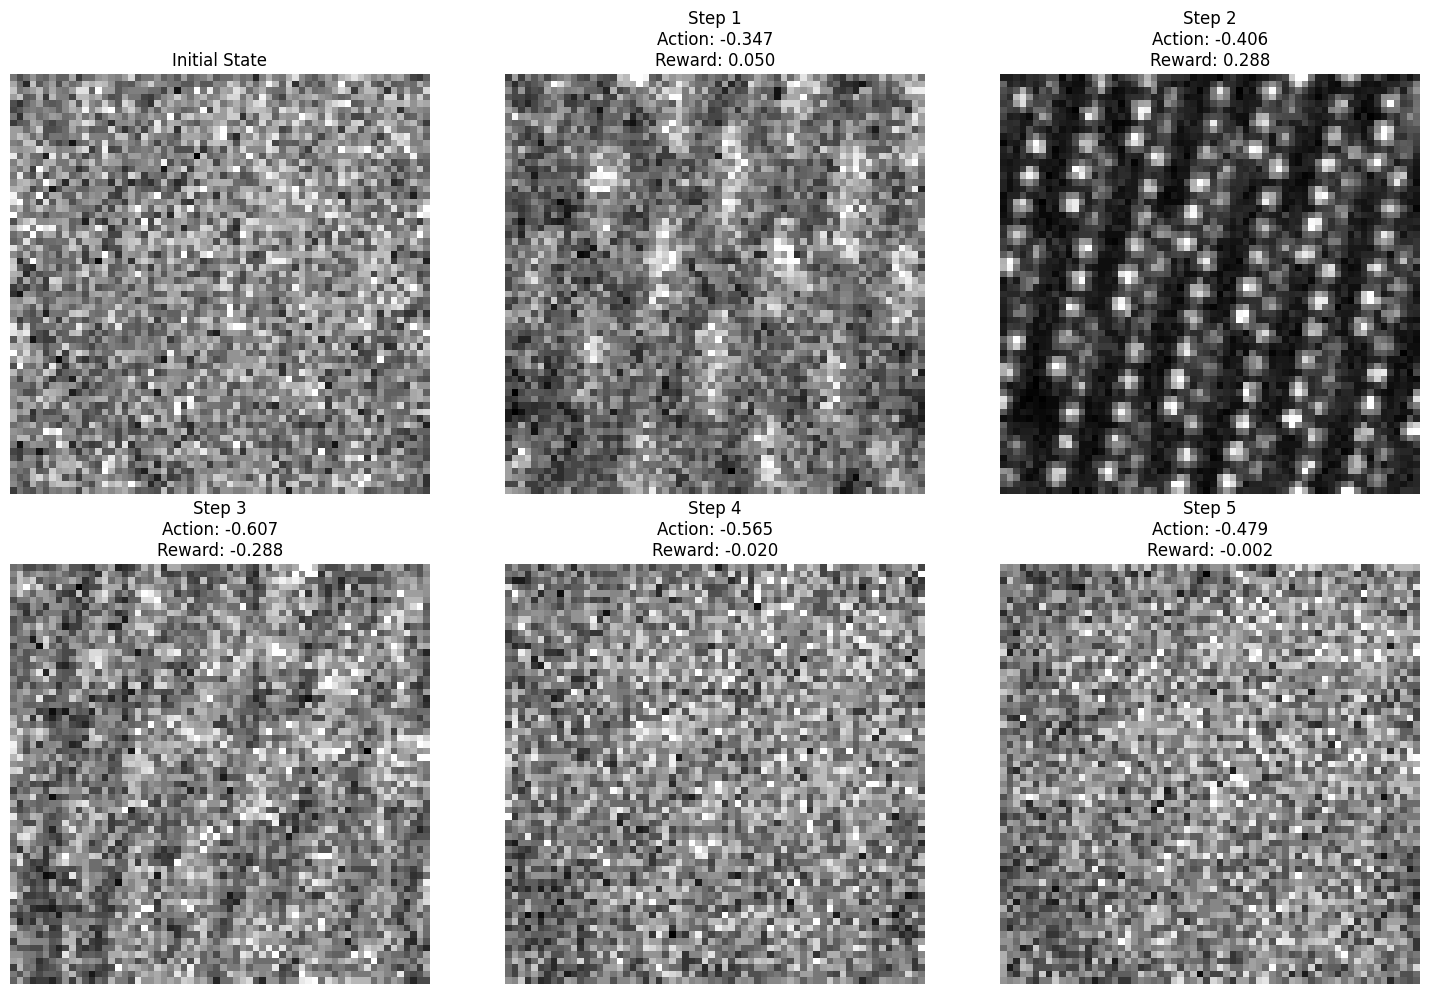

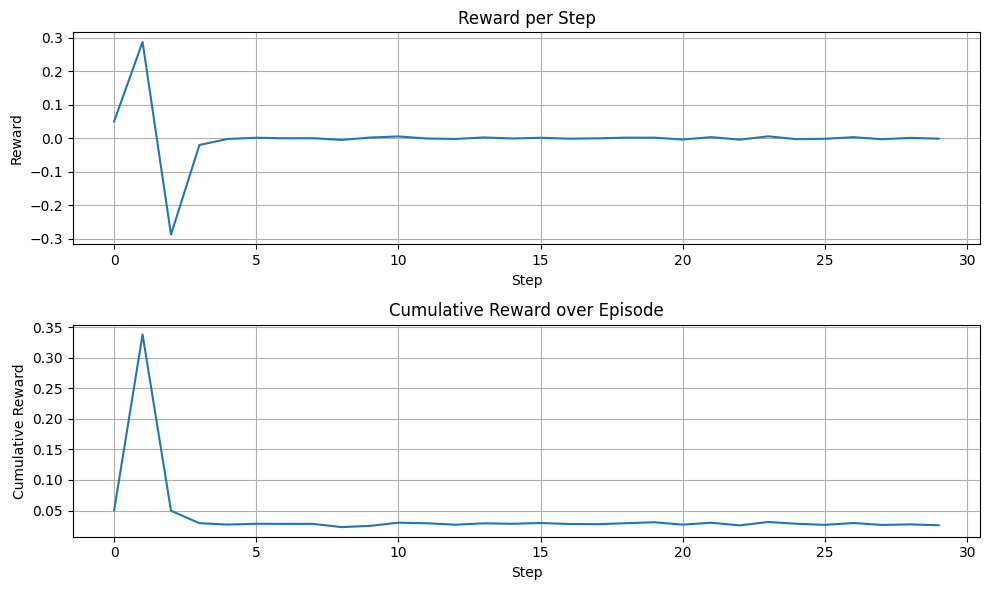

In [ ]:
import torch

# Initialize Ray if not already initialized
ray.init(ignore_reinit_error=True, include_dashboard=False, num_cpus=2)

# Load the trained model from checkpoint
checkpoint_path = os.path.abspath("rllib_checkpoints")
print(f"Loading checkpoint from: {checkpoint_path}")

trainer = PPO(config=config)
trainer.restore(checkpoint_path)

# Create environment for testing
env = STEM_environment(config=simulation_parameters)

# Run a test episode
print("\n" + "="*60)
print("Running test episode with trained policy...")
print("="*60)

obs, info = env.reset(seed=42)
done = False
total_reward = 0
step_count = 0
observations = [obs]
actions_taken = []
rewards = []

# Get the RLModule directly
rl_module = trainer.get_module()

while not done:
    # Convert observation to PyTorch tensor and add batch dimension
    obs_tensor = torch.from_numpy(obs).float().unsqueeze(0)
    
    # Forward pass through the module
    output = rl_module.forward_inference({"obs": obs_tensor})
    
    # Extract action from output
    # The output structure depends on your action space type
    if "action_dist_inputs" in output:
        # For continuous actions, we can sample from the distribution
        action = output["action_dist_inputs"][0]  # Remove batch dim
    elif "actions" in output:
        action = output["actions"][0]  # Remove batch dim
    else:
        # Fallback: try to get any action-like tensor
        action = list(output.values())[0][0]
    
    # Convert to numpy if it's a tensor
    if hasattr(action, "detach"):
        action = action.detach().cpu().numpy()
    
    # Extract scalar if it's an array (handle both single and multi-dimensional)
    if isinstance(action, np.ndarray):
        if action.size == 1:
            action = float(action.flatten()[0])
        else:
            action = action.flatten()[0]  # Take first element if multiple
    
    actions_taken.append(action)
    
    obs, reward, terminated, truncated, info = env.step(action)
    observations.append(obs)
    rewards.append(reward)
    
    total_reward += reward
    step_count += 1
    done = terminated or truncated
    
    if step_count % 5 == 0:
        print(f"Step {step_count}: action={action:.4f}, reward={reward:.4f}, cumulative={total_reward:.4f}, focus={env._last_metric:.4f}")

print(f"\n=== Episode Results ===")
print(f"Total steps: {step_count}")
print(f"Total reward: {total_reward:.4f}")
print(f"Mean reward per step: {np.mean(rewards):.4f}")
print(f"Final focus metric: {env._last_metric:.4f}")
print(f"Final state: {env.state}")

# Visualize the episode
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot first 6 observations
for i in range(min(6, len(observations))):
    axes[i].imshow(observations[i][:,:,0], cmap='gray')
    if i == 0:
        axes[i].set_title('Initial State')
    else:
        axes[i].set_title(f'Step {i}\nAction: {actions_taken[i-1]:.3f}\nReward: {rewards[i-1]:.3f}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('trained_model_episode.png', dpi=150)
print(f"\nSaved visualization to trained_model_episode.png")

# Plot reward trajectory
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(rewards)
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward per Step')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(np.cumsum(rewards))
plt.xlabel('Step')
plt.ylabel('Cumulative Reward')
plt.title('Cumulative Reward over Episode')
plt.grid(True)

plt.tight_layout()
plt.savefig('trained_model_rewards.png', dpi=150)
print(f"Saved reward plots to trained_model_rewards.png")

ray.shutdown()